## Differentially Expressed Genes using DeSeq2

In [1]:
# Ensure plots render inline
options(jupyter.plot_mimetypes = c("image/png"))
# Globally suppress warning messages 
options(suppressPackageStartupMessages = FALSE)

#### Load Library 

In [2]:
#install.packages("BiocManager")
#BiocManager::install(version = "3.18")  

#BiocManager::install("DESeq2")

In [3]:
# Suppress meassages
suppressPackageStartupMessages({
  suppressWarnings({
    library(readr)
    library(DESeq2)
    library(ggplot2)
    library(tidyverse)
  })
})


In [4]:
# Load data 
# Ths data is from GSE164073 
count_matrix <- read_csv("/home/jovyan/GSE164073_Eye_count_matrix.csv", show_col_types = FALSE)  
dim(count_matrix)
head(count_matrix, 3)

[1] 27946    19

Gene,MW1_cornea_mock_1,MW2_cornea_mock_2,MW3_cornea_mock_3,MW4_cornea_CoV2_1,MW5_cornea_CoV2_2,MW6_cornea_CoV2_3,MW7_limbus_mock_1,MW8_limbus_mock_2,MW9_limbus_mock_3,MW10_limbus_CoV2_1,MW11_limbus_CoV2_2,MW12_limbus_CoV2_3,MW13_sclera_mock_1,MW14_sclera_mock_2,MW15_sclera_mock_3,MW16_sclera_CoV2_1,MW17_sclera_CoV2_2,MW18_sclera_CoV2_3
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A1BG,91,131,86,77,69,72,128,97,112,96,95,82,82,70,101,91,78,84
A1BG-AS1,292,284,271,232,250,241,444,311,355,274,298,322,233,241,243,279,203,278
A1CF,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### Preprocessing

In [5]:
count_matrix <- as.data.frame(count_matrix)  # convert tibble to data.frame

# Set gene symbols as row names
rownames(count_matrix) <- count_matrix$Gene

# Remove the Gene column so only numeric counts remain
count_matrix <- count_matrix[, -which(names(count_matrix) == "Gene")]

# Ensure counts are integers
count_matrix[] <- lapply(count_matrix, function(x) as.integer(round(x)))

# check data
#head(count_matrix, 3)


## Metadata

In [6]:
sample_names <- colnames(count_matrix)

# Adjust as needed to match your dataset
tissue <- c(rep("cornea",6), rep("limbus",6), rep("sclera",6))
condition <- c(rep(c("mock","CoV2"), each=3), rep(c("mock","CoV2"), each=3), rep(c("mock","CoV2"), each=3))

# Build colData
colData <- data.frame(tissue = tissue, condition = condition)
rownames(colData) <- sample_names

# Check
nrow(colData)   # should be 18
ncol(count_matrix)  # should be 18
head(colData,10)

[1] 18

[1] 18

,tissue,condition
,<chr>,<chr>
MW1_cornea_mock_1,cornea,mock
MW2_cornea_mock_2,cornea,mock
MW3_cornea_mock_3,cornea,mock
MW4_cornea_CoV2_1,cornea,CoV2
MW5_cornea_CoV2_2,cornea,CoV2
MW6_cornea_CoV2_3,cornea,CoV2
MW7_limbus_mock_1,limbus,mock
MW8_limbus_mock_2,limbus,mock
MW9_limbus_mock_3,limbus,mock


#### Create the DESeqDataSet Object

In [7]:

dds <- DESeqDataSetFromMatrix(
  countData =  round(count_matrix),
  colData = colData,
  design = ~ condition   
)

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”


In [8]:
##  Filtering
dds <- dds[rowSums(counts(dds)) >= 10, ]  # keep genes with ≥10 counts across all samples

In [9]:
## Run DESeq2
dds <- DESeq(dds)
res <- results(dds, pAdjustMethod = "BH") # adjusted p-values (FDR) using the Benjamini-Hochberg correction method


estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



In [10]:
head(res)

log2 fold change (MLE): condition mock vs CoV2 
Wald test p-value: condition mock vs CoV2 
DataFrame with 6 rows and 6 columns
           baseMean log2FoldChange     lfcSE      stat    pvalue      padj
          <numeric>      <numeric> <numeric> <numeric> <numeric> <numeric>
A1BG      90.387769      0.1449492  0.117706  1.231452 0.2181537  0.775805
A1BG-AS1 278.108499      0.0490181  0.112583  0.435394 0.6632767  0.952794
A2M      872.917260      0.8098853  0.741530  1.092182 0.2747531  0.812063
A2M-AS1   11.330923     -0.4885154  0.252834 -1.932160 0.0533398        NA
A2ML1      0.578192      1.1192600  1.825458  0.613139 0.5397843        NA
A3GALT2    0.685671      0.1302514  1.222775  0.106521 0.9151688        NA

#### Differentially Expressed Genes by Tissue

In [11]:
# Filter DEGs: Adjusted p-value < 0.05 and |log2FoldChange| > 1
DEGs <- res[which(res$padj < 0.05 & abs(res$log2FoldChange) >  0.5), ]

# Extract tissue information from colData
tissue_info <- colData$tissue

# Count DEGs by tissue
deg_count_by_tissue <- sapply(unique(tissue_info), function(tissue) {
  # Get the indices of DEGs for this tissue
  deg_tissue_subset <- DEGs[tissue_info == tissue, ]
  # Count the number of DEGs for this tissue
  return(nrow(deg_tissue_subset))
})

# Print the number of DEGs for each tissue
cat("Number of DEGs by tissue:\n")
print(deg_count_by_tissue)

Number of DEGs by tissue:
cornea limbus sclera 
    28     24     24 


### Differential Expression by Tissue

In [12]:
# First, subset the `dds` object for each tissue

# For cornea
dds_cornea <- dds[, colData(dds)$tissue == "cornea"]
dds_cornea <- DESeq(dds_cornea)
res_cornea <- results(dds_cornea)

# For limbus
dds_limbus <- dds[, colData(dds)$tissue == "limbus"]
dds_limbus <- DESeq(dds_limbus)
res_limbus <- results(dds_limbus)

# For sclera
dds_sclera <- dds[, colData(dds)$tissue == "sclera"]
dds_sclera <- DESeq(dds_sclera)
res_sclera <- results(dds_sclera)


using pre-existing size factors

estimating dispersions

found already estimated dispersions, replacing these

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

using pre-existing size factors

estimating dispersions

found already estimated dispersions, replacing these

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

using pre-existing size factors

estimating dispersions

found already estimated dispersions, replacing these

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



In [13]:
# Filter DEGs for each tissue based on p-value and log2FoldChange
DEGs_tissue_cornea <- res_cornea[which(res_cornea$padj < 0.05 & abs(res_cornea$log2FoldChange) > 0.5), ]
DEGs_tissue_limbus <- res_limbus[which(res_limbus$padj < 0.05 & abs(res_limbus$log2FoldChange) > 0.5), ]
DEGs_tissue_sclera <- res_sclera[which(res_sclera$padj < 0.05 & abs(res_sclera$log2FoldChange) > 0.5), ]


In [14]:
# Extract gene names for each tissue
genes_cornea <- rownames(DEGs_tissue_cornea)  # DEGs in cornea
genes_limbus <- rownames(DEGs_tissue_limbus)  # DEGs in limbus
genes_sclera <- rownames(DEGs_tissue_sclera)  # DEGs in sclera

cat("Number of DEGs in cornea:", length(genes_cornea))

Number of DEGs in cornea: 599

In [15]:
# Number of DEGs in each tissue
cat("Number of DEGs in cornea:", nrow(DEGs_tissue_cornea), "\n")
cat("Number of DEGs in limbus:", nrow(DEGs_tissue_limbus), "\n")
cat("Number of DEGs in sclera:", nrow(DEGs_tissue_sclera), "\n")



Number of DEGs in cornea: 599 
Number of DEGs in limbus: 493 
Number of DEGs in sclera: 593 


### Overlap Between cornea and limbus

In [16]:
# Find overlap of DEGs between cornea and limbus
overlap_cornea_limbus <- intersect(genes_cornea, genes_limbus)

# Print the overlap
#cat("Overlap of DEGs between cornea and limbus:\n")
#print(overlap_cornea_limbus)

# Number of overlapping DEGs
cat("Number of overlapping DEGs between cornea and limbus:\n")
print(length(overlap_cornea_limbus))


Number of overlapping DEGs between cornea and limbus:
[1] 121


In [17]:
# Find overlap of DEGs between cornea and sclera
overlap_cornea_sclera <- intersect(genes_cornea, genes_sclera)

# Print the overlap
#cat("Overlap of DEGs between cornea and sclera:\n")
#print(overlap_cornea_sclera)

# Number of overlapping DEGs
cat("Number of overlapping DEGs between cornea and sclera:\n")
print(length(overlap_cornea_sclera))

Number of overlapping DEGs between cornea and sclera:
[1] 204


In [18]:
# Find overlap of DEGs between limbus and sclera
overlap_limbus_sclera <- intersect(genes_limbus, genes_sclera)

# Print the overlap
#cat("Overlap of DEGs between limbus and sclera:\n")
#print(overlap_limbus_sclera)

# Number of overlapping DEGs
cat("Number of overlapping DEGs between limbus and sclera:\n")
print(length(overlap_limbus_sclera))


Number of overlapping DEGs between limbus and sclera:
[1] 158


In [19]:
### # Find overlap of DEGs across cornea, limbus, and sclera
overlap_all_tissues <- Reduce(intersect, list(genes_cornea, genes_limbus, genes_sclera))

# Print the overlap
#cat("Overlap of DEGs across cornea, limbus, and sclera:\n")
#print(overlap_all_tissues)

# Number of overlapping DEGs across all three tissues
cat("Number of overlapping DEGs across all three tissues:\n")
print(length(overlap_all_tissues))


Number of overlapping DEGs across all three tissues:
[1] 70


In [20]:
# Install and load VennDiagram package if not already installed
install.packages("VennDiagram")
library(VennDiagram)


Installing package into ‘/home/jovyan/R/x86_64-conda-linux-gnu-library/4.3’
(as ‘lib’ is unspecified)

Loading required package: grid

Loading required package: futile.logger



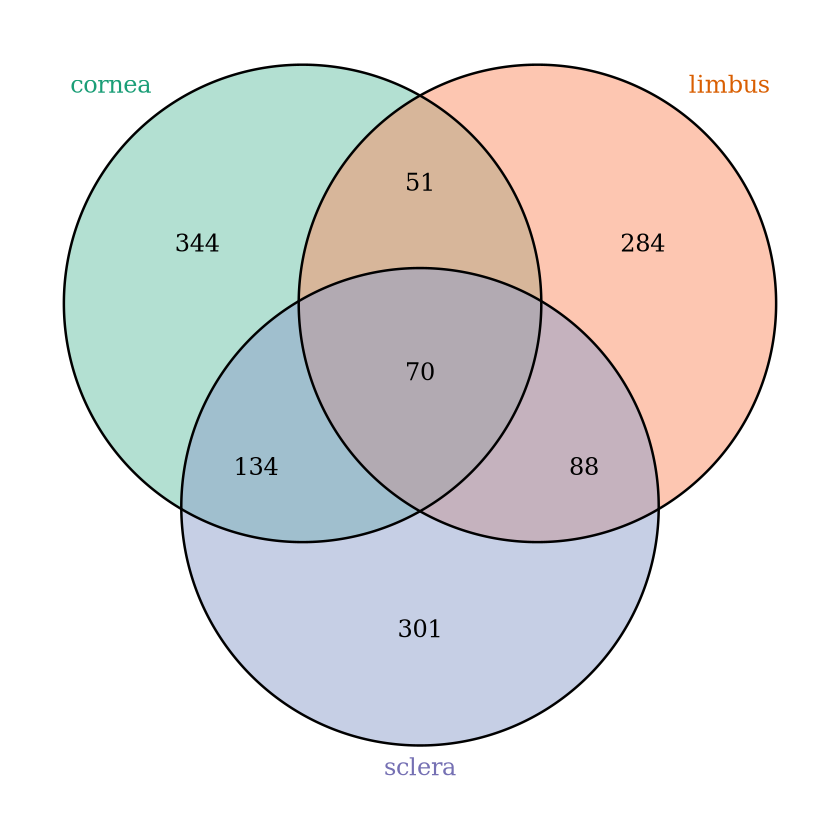

In [21]:
# Generate Venn diagram 
venn.plot <- venn.diagram(
  x = list(
    'cornea' = genes_cornea, 
    'limbus' = genes_limbus, 
    'sclera' = genes_sclera
  ),
  category.names = c('cornea', 'limbus', 'sclera'),
  filename = NULL,  # No file output
  output = TRUE,
  fill = c("#66c2a5", "#fc8d62", "#8da0cb"),  # Custom fill colors
  alpha = 0.5,
  cat.cex = 1.2,
  cat.col = c("#1b9e77", "#d95f02", "#7570b3"),
  cex = 1.2,
  margin = 0.05
)

# Suppress grid background (no extra lines or frame)
grid.draw(venn.plot)

### Upregulated and Downregulated Genes

In [22]:
# Filtering Up and Down regulated genes with log2FC threshold
count_up_down <- function(res, tissue, fc_threshold = 0.5) {
  # Keep only significant genes
  sig <- res[!is.na(res$padj) & res$padj < 0.05, ]
  
  # Count upregulated and downregulated based on log2FC threshold
  up <- sum(sig$log2FoldChange > fc_threshold)
  down <- sum(sig$log2FoldChange < -fc_threshold)
  
  # Print results
  cat(tissue, "- Upregulated:", up, "Downregulated:", down, "\n")
  
  # Return as data frame
  return(data.frame(tissue = tissue, up = up, down = down))
}


# Print the result
summary_table <- rbind(
  count_up_down(res_cornea, "Cornea"),
  count_up_down(res_limbus, "Limbus"),
  count_up_down(res_sclera, "Sclera")
)


Cornea - Upregulated: 326 Downregulated: 273 
Limbus - Upregulated: 344 Downregulated: 149 
Sclera - Upregulated: 340 Downregulated: 253 


#### Plotting the Number of DEGs by Tissue

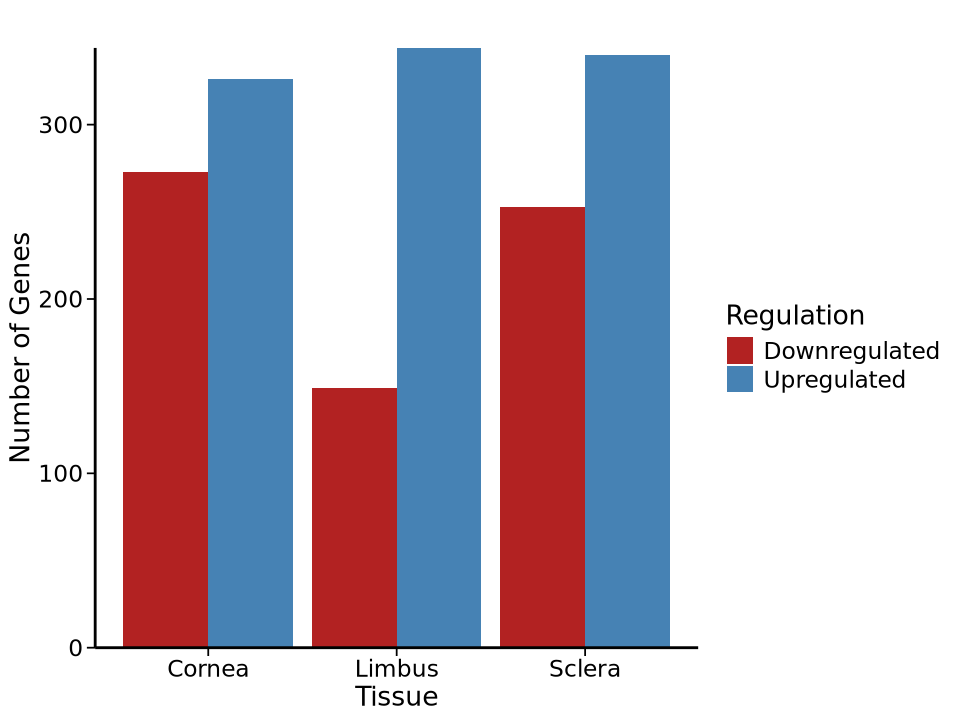

In [23]:
library(tidyr)
library(ggplot2)

#set graph size 
options(repr.plot.width = 8, repr.plot.height = 6)

# Convert wide table to long format
summary_long <- pivot_longer(
  summary_table,
  cols = c(up, down),
  names_to = "Regulation",
  values_to = "count"
)

# Make "Up" and "Down" more readable
summary_long$Regulation <- ifelse(summary_long$Regulation == "up", "Upregulated", "Downregulated")

# Set factor levels so Upregulated comes first
summary_long$regulation <- factor(summary_long$Regulation, levels = c("Upregulated", "Downregulated"))

# Plot
ggplot(summary_long, aes(x = tissue, y = count, fill = Regulation)) +
  geom_bar(stat = "identity", position = "dodge") +
  theme_minimal() +
 labs(title = "",
       x = "Tissue",
       y = "Number of Genes") +
  scale_fill_manual(values = c("Upregulated" = "steelblue", "Downregulated" = "firebrick")) +
  scale_y_continuous(expand = c(0, 0)) +     # Remove space below bars on y-axis
  #scale_x_discrete(expand = c(0, 0)) +       # Remove space on x-axis (left/right)
  theme_minimal() +
  theme(
    panel.grid = element_blank(),               # remove grid lines
   
    axis.ticks = element_line(color = "black"),
    axis.ticks.length = unit(5, "pt"),
    text = element_text(size = 16),             # increase overall text size
    axis.title = element_text(size = 16),       # axis titles
    axis.text = element_text(size = 14, color = "black"),        # axis tick labels
    legend.title = element_text(size = 16, color = "black"),     # legend title
    legend.text = element_text(size = 14),      # legend labels
      axis.line = element_line(color = "black", linewidth = 0.8)  # black axis lines
            
  )


### Pathway Analysis

In [24]:
#BiocManager::install("org.Hs.eg.db") 
# If not installed
if(!require(clusterProfiler)) BiocManager::install("clusterProfiler")
if(!require(org.Hs.eg.db)) BiocManager::install("org.Hs.eg.db")  # human genes
if(!require(enrichplot)) BiocManager::install("enrichplot")      # for plotting



Loading required package: clusterProfiler



clusterProfiler v4.17.0 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

S Xu, E Hu, Y Cai, Z Xie, X Luo, L Zhan, W Tang, Q Wang, B Liu, R Wang,
W Xie, T Wu, L Xie, G Yu. Using clusterProfiler to characterize
multiomics data. Nature Protocols. 2024, 19(11):3292-3320


Attaching package: ‘clusterProfiler’


The following object is masked from ‘package:purrr’:

    simplify


The following object is masked from ‘package:IRanges’:

    slice


The following object is masked from ‘package:S4Vectors’:

    rename


The following object is masked from ‘package:stats’:

    filter


Loading required package: org.Hs.eg.db

Loading required package: AnnotationDbi


Attaching package: ‘AnnotationDbi’


The following object is masked from ‘package:clusterProfiler’:

    select


The following object is masked from ‘package:dplyr’:

    select




Loading required package: enrichplot



In [25]:
library(clusterProfiler)
library(org.Hs.eg.db)
library(enrichplot)


#### Create a function to extract up/downregulated gene symbols

In [26]:
library(clusterProfiler)
library(org.Hs.eg.db)

get_DEGs <- function(res, fc_threshold = 0.5) {
  sig <- res[!is.na(res$padj) & res$padj < 0.05, ]
  
  # Upregulated genes
  up_genes <- rownames(sig)[sig$log2FoldChange > fc_threshold]
  up_entrez <- mapIds(org.Hs.eg.db, keys = up_genes, column = "ENTREZID", keytype = "SYMBOL", multiVals = "first")
  
  # Downregulated genes
  down_genes <- rownames(sig)[sig$log2FoldChange < -fc_threshold]
  down_entrez <- mapIds(org.Hs.eg.db, keys = down_genes, column = "ENTREZID", keytype = "SYMBOL", multiVals = "first")
  
  return(list(up = na.omit(up_entrez), down = na.omit(down_entrez)))
}


#### Run KEGG enrichment for each tissue

In [27]:
# For Cornea
cornea_DEGs <- get_DEGs(res_cornea)

kegg_up_cornea <- enrichKEGG(gene = cornea_DEGs$up, organism = "hsa", pvalueCutoff = 0.05)
kegg_down_cornea <- enrichKEGG(gene = cornea_DEGs$down, organism = "hsa", pvalueCutoff = 0.05)

# For Limbus
limbus_DEGs <- get_DEGs(res_limbus)
kegg_up_limbus <- enrichKEGG(gene = limbus_DEGs$up, organism = "hsa", pvalueCutoff = 0.05)
kegg_down_limbus <- enrichKEGG(gene = limbus_DEGs$down, organism = "hsa", pvalueCutoff = 0.05)

# For Sclera
sclera_DEGs <- get_DEGs(res_sclera)
kegg_up_sclera <- enrichKEGG(gene = sclera_DEGs$up, organism = "hsa", pvalueCutoff = 0.05)
kegg_down_sclera <- enrichKEGG(gene = sclera_DEGs$down, organism = "hsa", pvalueCutoff = 0.05)



'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

Reading KEGG annotation online: "https://rest.kegg.jp/link/hsa/pathway"...

Reading KEGG annotation online: "https://rest.kegg.jp/list/pathway/hsa"...

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns



#### Plot KEGG enrichment

In [28]:
p1 <- barplot(kegg_up_cornea, showCategory = 10, title = "Cornea - Upregulated KEGG")
p2 <- barplot(kegg_down_cornea, showCategory = 10, title = "Cornea - Downregulated KEGG")

p3 <- barplot(kegg_up_limbus, showCategory = 10, title = "Limbus - Upregulated KEGG")
p4 <- barplot(kegg_down_limbus, showCategory = 10, title = "Limbus - Downregulated KEGG")

p5 <- barplot(kegg_up_sclera, showCategory = 10, title = "Sclera - Upregulated KEGG")
p6 <- barplot(kegg_down_sclera, showCategory = 10, title = "Sclera - Downregulated KEGG")



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine


The following object is masked from ‘package:Biobase’:

    combine


The following object is masked from ‘package:BiocGenerics’:

    combine




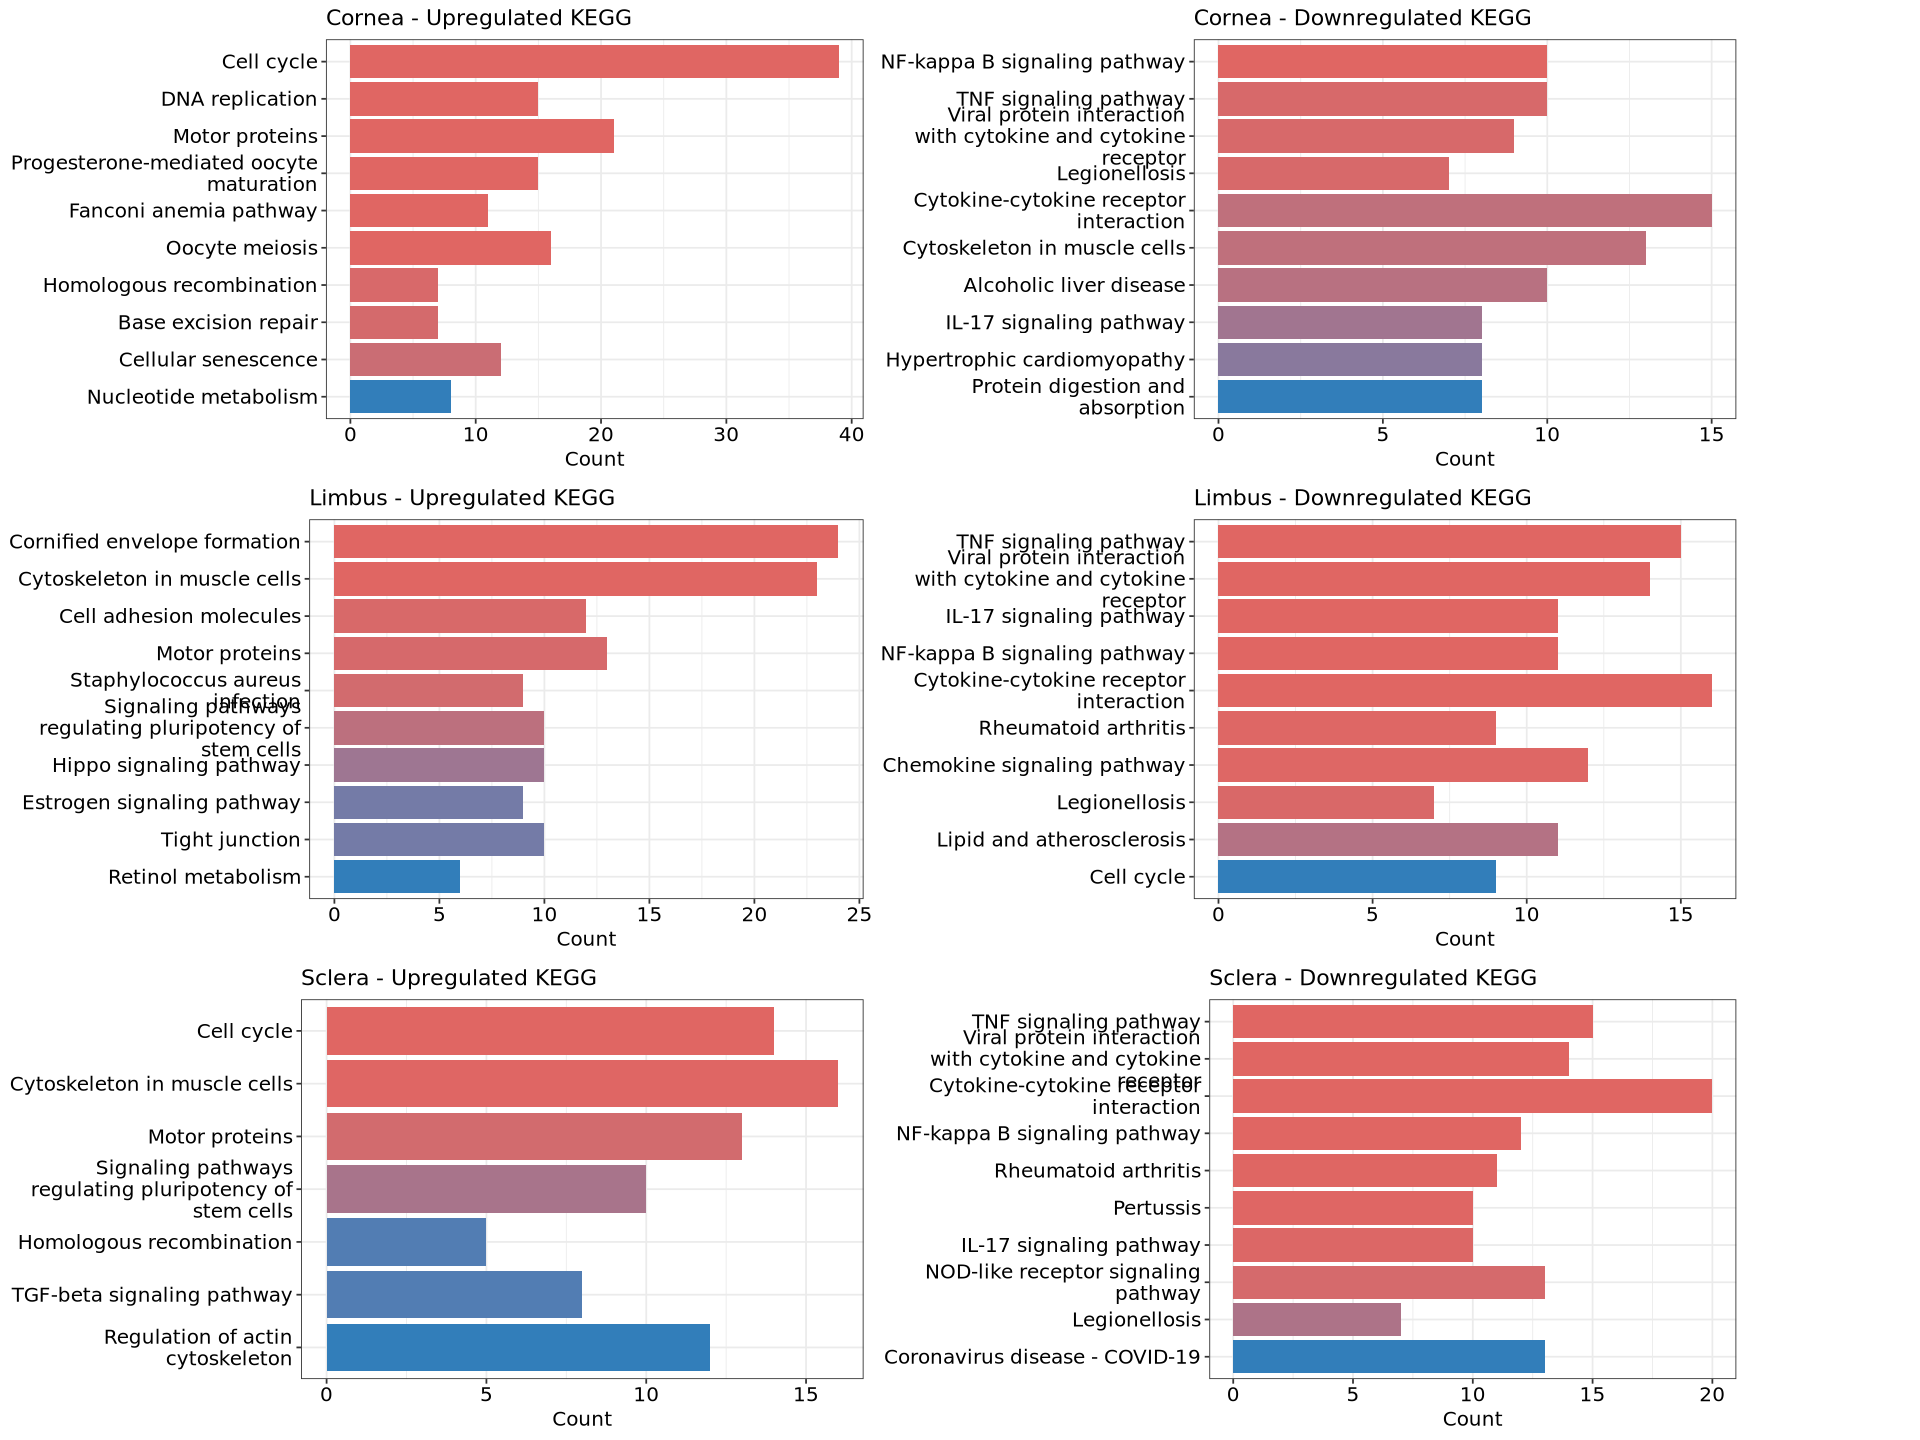

In [30]:
library(gridExtra)
library(grid)
library(gtable)

options(repr.plot.width = 16, repr.plot.height = 12)

# Function to extract legend
get_legend <- function(myplot) {
  tmp <- ggplotGrob(myplot)
  leg <- gtable::gtable_filter(tmp, "guide-box")
  return(leg)
}

# Remove individual legends
plots <- lapply(list(p1, p2, p3, p4, p5, p6), function(x) x + theme(legend.position = "none"))

# Extract shared legend from first plot
shared_legend <- get_legend(p1)

# Arrange plots in 2 columns, legend on the right
grid.arrange(
  arrangeGrob(grobs = plots, ncol = 2),
  shared_legend,
  ncol = 2,
  widths = c(10, 1)  # left column = plots, right column = legend
)

### Functional Analysis

In [31]:
library(clusterProfiler)
library(org.Hs.eg.db)

# Function to run GO enrichment
run_GO <- function(entrez_genes) {
  if(length(entrez_genes) == 0) return(NULL)  # skip if no genes
  go_result <- enrichGO(
    gene = entrez_genes,
    OrgDb = org.Hs.eg.db,
    keyType = "ENTREZID",
    ont = "BP",
    pAdjustMethod = "BH",
    pvalueCutoff = 0.05,
    qvalueCutoff = 0.2,
    readable = TRUE
  )
  return(go_result)
}

# For Cornea
go_up_cornea <- run_GO(cornea_DEGs$up)
go_down_cornea <- run_GO(cornea_DEGs$down)

# For Limbus
go_up_limbus <- run_GO(limbus_DEGs$up)
go_down_limbus <- run_GO(limbus_DEGs$down)

# For Sclera
go_up_sclera <- run_GO(sclera_DEGs$up)
go_down_sclera <- run_GO(sclera_DEGs$down)



In [32]:
# Barplot for top 10 GO terms
goP1 <- barplot(go_up_cornea, showCategory = 10, title = "Cornea - Upregulated GO")
goP2 <- barplot(go_down_cornea, showCategory = 10, title = "Cornea - Downregulated GO")
goP3 <- barplot(go_up_limbus, showCategory = 10, title = "Limbus - Upregulated GO")
goP4 <- barplot(go_down_limbus, showCategory = 10, title = "Limbus - Downregulated GO")
goP5 <- barplot(go_up_sclera, showCategory = 10, title = "Sclera - Upregulated GO")
goP6 <- barplot(go_down_sclera, showCategory = 10, title = "Sclera - Downregulated GO")


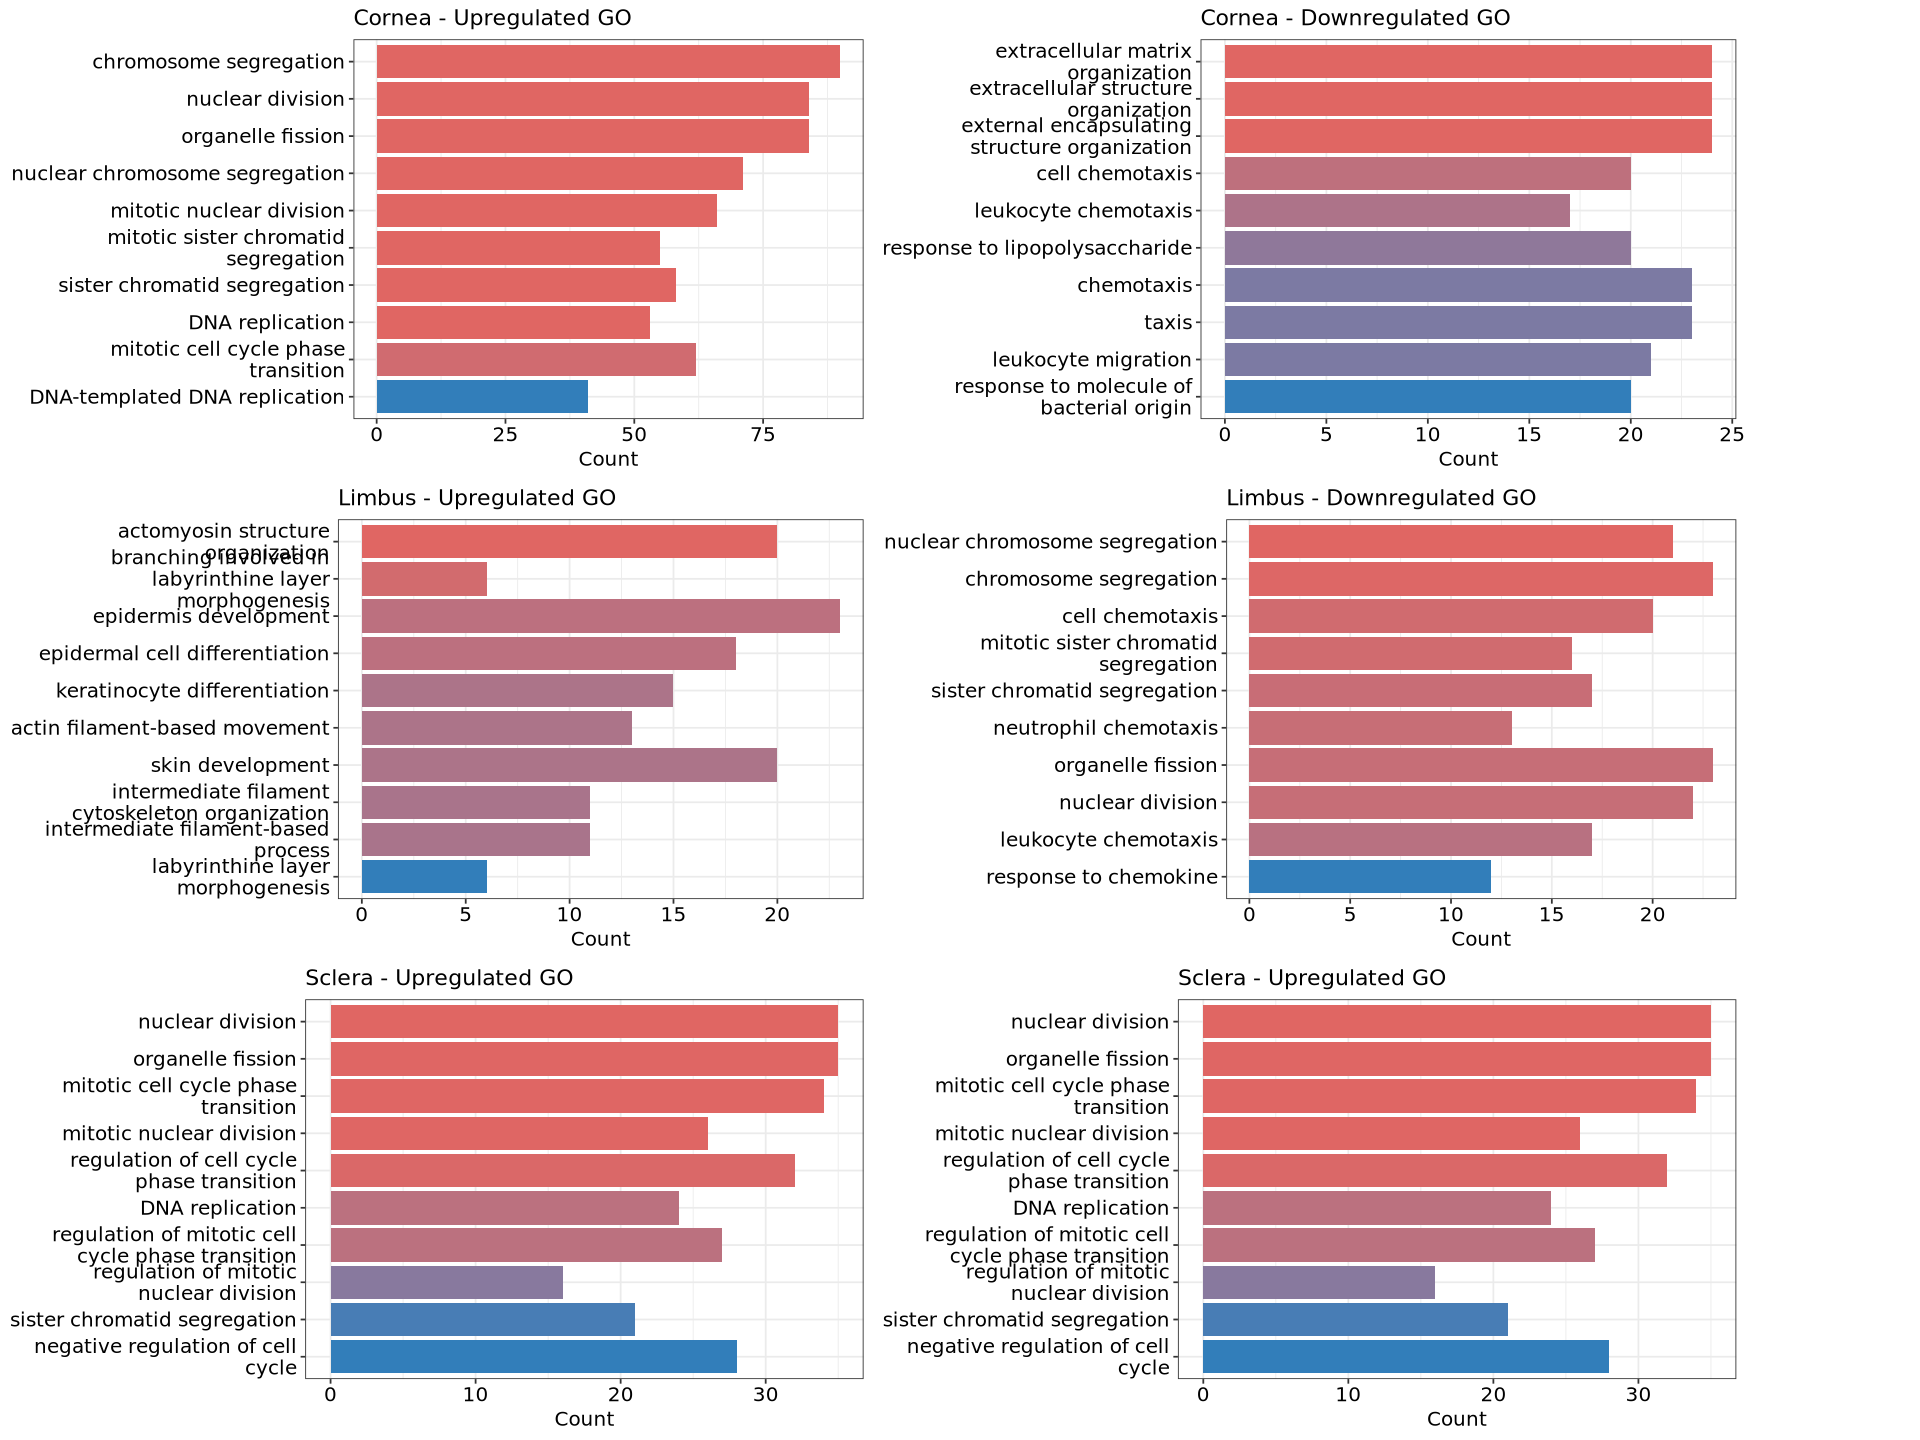

In [33]:
options(repr.plot.width = 16, repr.plot.height = 12)
# Function to extract legend
get_legend <- function(myplot) {
  tmp <- ggplotGrob(myplot)
  leg <- gtable::gtable_filter(tmp, "guide-box")
  return(leg)
}

# Remove individual legends
plots <- lapply(list(goP1, goP2, goP3, goP4, goP5, goP5), function(x) x + theme(legend.position = "none"))

# Extract shared legend from first plot
shared_legend <- get_legend(p1)

# Arrange plots in 2 columns, legend on the right
grid.arrange(
  arrangeGrob(grobs = plots, ncol = 2),
  shared_legend,
  ncol = 2,
  widths = c(10, 1)  # left column = plots, right column = legend
)